Rest Part of EDA (Sourish)

### Data source

This notebook originally read CSVs from Google Colab (`/content`, Google Drive). It now loads the **same tables from the project workbook** `Dataviz_proj_all_datasets.xlsx`, which is **downloaded separately** (no longer stored in git). Place the workbook at the repository root, or set the `DVD_WORKBOOK` environment variable to its path, then run all cells.

In [1]:
# --- Portable data loader (replaces the original Colab /content paths) ---
import os
from pathlib import Path
import pandas as pd

_ROOT = Path.cwd()
while _ROOT != _ROOT.parent and not (_ROOT / "Dataviz_proj_all_datasets.xlsx").exists():
    _ROOT = _ROOT.parent
WORKBOOK = Path(os.environ.get("DVD_WORKBOOK", _ROOT / "Dataviz_proj_all_datasets.xlsx"))

# CSV base name -> workbook sheet name (some sheet names are truncated in the workbook)
_SHEET = {
    "customers_dataset": "customers_dataset",
    "orders_dataset": "orders_dataset",
    "order_items_dataset": "order_items_dataset",
    "order_reviews_dataset": "order_reviews_dataset",
    "order_payments_dataset": "order_payments_dataset",
    "products_dataset": "products_dataset",
    "sellers_dataset": "sellers_dataset",
    "geolocation_dataset": "geolocation_dataset",
    "marketing_qualified_leads_dataset": "marketing_qualified_leads_datas",
    "closed_deals_dataset": "closed_deals",
    "product_category_name_translation": "product_category_name_translati",
}
_BOOK = pd.ExcelFile(WORKBOOK)

def load(name):
    """Load a dataset by its CSV base name from the project workbook."""
    key = os.path.basename(str(name)).replace(".csv", "")
    return pd.read_excel(_BOOK, sheet_name=_SHEET.get(key, key))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
orders = load("orders_dataset")


print("Dataset loaded successfully!")
print("Shape:", orders.shape)

orders.head()

Dataset loaded successfully!
Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
print("========== DATASET INFORMATION ==========")
orders.info()

print("\n========== COLUMN NAMES ==========")
print(orders.columns.tolist())

========== DATASET INFORMATION ==========
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

========== COLUMN NAMES ==========
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [5]:
missing = pd.DataFrame({
    'Missing_Count': orders.isnull().sum(),
    'Missing_Percentage': (orders.isnull().sum() / len(orders) * 100).round(2)
})

missing = missing.sort_values('Missing_Count', ascending=False)

print("========== MISSING VALUES ==========")
display(missing)

========== MISSING VALUES ==========


,Missing_Count,Missing_Percentage
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16
order_id,0,0.00
order_purchase_timestamp,0,0.00
order_status,0,0.00
customer_id,0,0.00
order_estimated_delivery_date,0,0.00


In [6]:
print("========== DUPLICATE CHECK ==========")

print("Duplicate rows:", orders.duplicated().sum())

print("Duplicate order IDs:", orders['order_id'].duplicated().sum())

print("\nUnique order IDs:", orders['order_id'].nunique())
print("Total rows:", len(orders))

========== DUPLICATE CHECK ==========


Duplicate rows: 0
Duplicate order IDs: 0



Unique order IDs: 99441
Total rows: 99441


In [7]:
status_count = orders['order_status'].value_counts()

print("========== ORDER STATUS ==========")
print(status_count)

status_percent = (
    orders['order_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n========== ORDER STATUS (%) ==========")
print(status_percent)

========== ORDER STATUS ==========
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

========== ORDER STATUS (%) ==========
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64


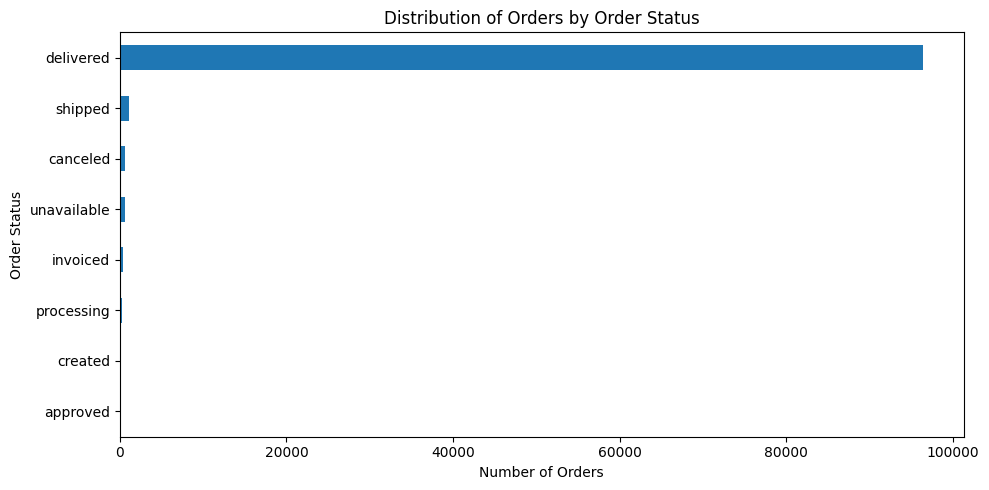

In [8]:
plt.figure(figsize=(10, 5))

status_count.sort_values(ascending=True).plot(kind='barh')

plt.title('Distribution of Orders by Order Status')
plt.xlabel('Number of Orders')
plt.ylabel('Order Status')

plt.tight_layout()
plt.show()

In [9]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print("Date conversion completed.")

orders[date_columns].dtypes

Date conversion completed.


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [10]:
print("========== ORDER DATE RANGE ==========")

print("Earliest order:",
      orders['order_purchase_timestamp'].min())

print("Latest order:",
      orders['order_purchase_timestamp'].max())

========== ORDER DATE RANGE ==========
Earliest order: 2016-09-04 21:15:19
Latest order: 2018-10-17 17:30:18


In [11]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = (
    orders.groupby('order_month')
    .size()
    .reset_index(name='order_count')
)

monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

monthly_orders.head()

,order_month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


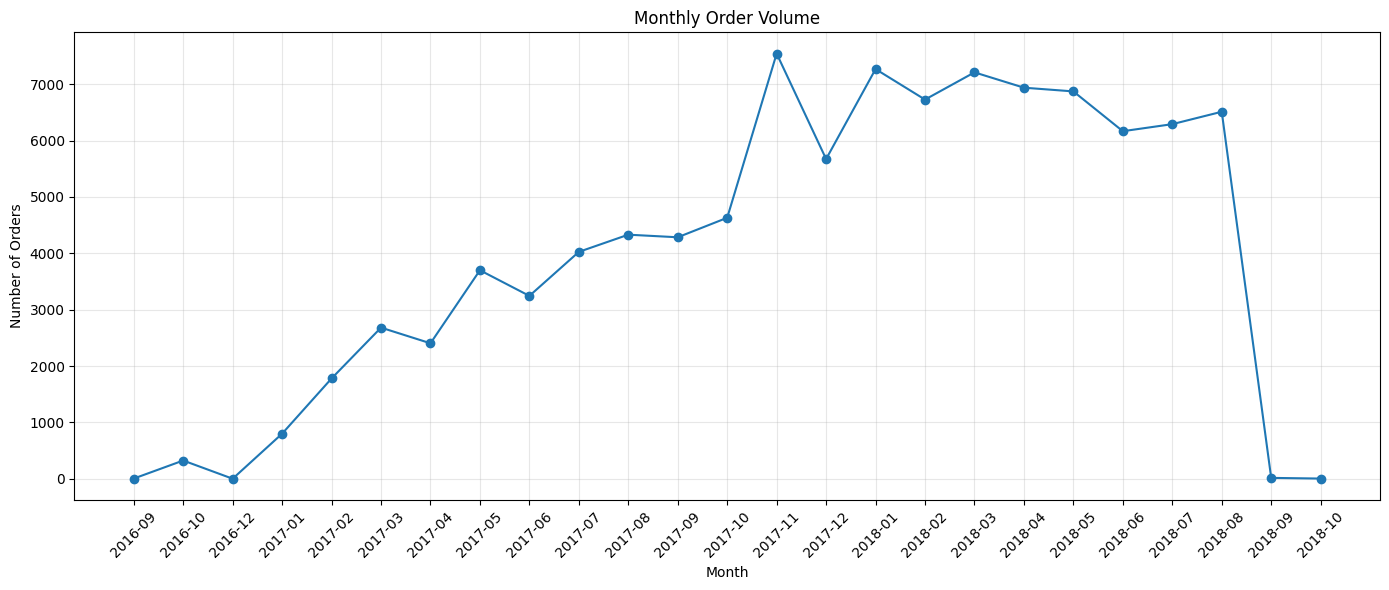

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_orders['order_month'],
    monthly_orders['order_count'],
    marker='o'
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

orders[['order_id',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'delivery_delay_days']].head(10)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-9.238171
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-26 10:57:55,2017-08-01,-5.543113
6,136cce7faa42fdb2cefd53fdc79a6098,NaT,2017-05-09,NaN
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-26 12:55:51,2017-06-07,-11.461215
8,76c6e866289321a7c93b82b54852dc33,2017-02-02 14:08:10,2017-03-06,-31.410995
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-08-16 17:14:30,2017-08-23,-6.281597


In [14]:
orders['delivery_status'] = np.where(
    orders['delivery_delay_days'].isna(),
    'Not Delivered',
    np.where(
        orders['delivery_delay_days'] <= 0,
        'Early / On-time',
        'Late'
    )
)

print(orders['delivery_status'].value_counts())

delivery_status
Early / On-time    88649
Late                7827
Not Delivered       2965
Name: count, dtype: int64


In [15]:
delivery_status_pct = (
    orders['delivery_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("========== DELIVERY STATUS (%) ==========")
print(delivery_status_pct)

========== DELIVERY STATUS (%) ==========
delivery_status
Early / On-time    89.15
Late                7.87
Not Delivered       2.98
Name: proportion, dtype: float64


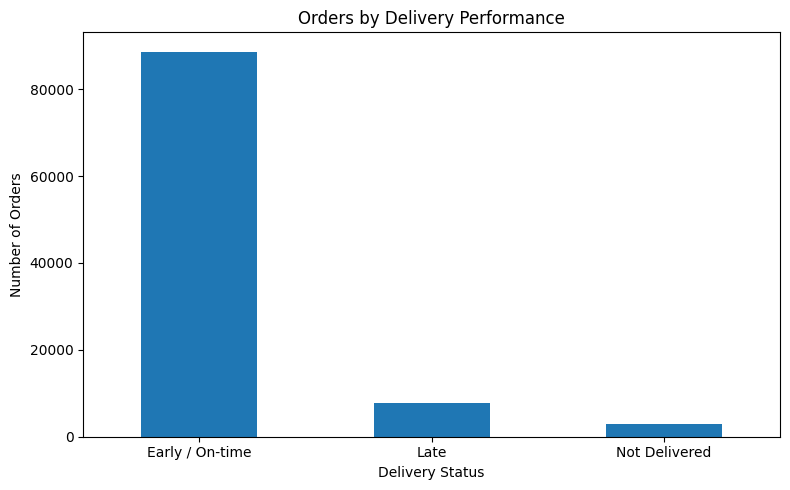

In [16]:
delivery_count = orders['delivery_status'].value_counts()

plt.figure(figsize=(8, 5))

delivery_count.plot(kind='bar')

plt.title('Orders by Delivery Performance')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
delivered = orders[
    orders['order_delivered_customer_date'].notna()
].copy()

print("Number of delivered orders:", len(delivered))

print("\n========== DELIVERY DELAY STATISTICS ==========")

print(
    delivered['delivery_delay_days']
    .describe()
)

Number of delivered orders: 96476

========== DELIVERY DELAY STATISTICS ==========
count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64


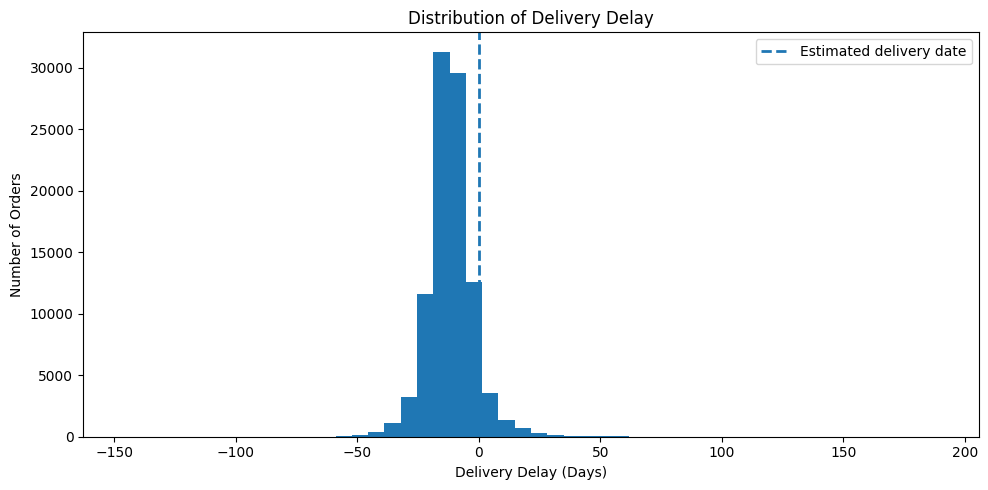

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    delivered['delivery_delay_days'].dropna(),
    bins=50
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=2,
    label='Estimated delivery date'
)

plt.title('Distribution of Delivery Delay')
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Number of Orders')

plt.legend()
plt.tight_layout()
plt.show()

In [19]:
def delay_group(days):
    if pd.isna(days):
        return 'Not Delivered'
    elif days <= 0:
        return 'Early / On-time'
    elif days <= 3:
        return '1–3 days late'
    elif days <= 7:
        return '4–7 days late'
    elif days <= 14:
        return '8–14 days late'
    else:
        return '>14 days late'

orders['delay_group'] = orders['delivery_delay_days'].apply(delay_group)

print(
    orders['delay_group'].value_counts()
)

delay_group
Early / On-time    88649
Not Delivered       2965
1–3 days late       2662
4–7 days late       1819
8–14 days late      1791
>14 days late       1555
Name: count, dtype: int64


In [20]:
reviews = load("order_reviews_dataset")

print("Reviews shape:", reviews.shape)

reviews.head()

Reviews shape: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [21]:
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [22]:
# Keep only the columns we need from the reviews table
review_data = reviews[['order_id', 'review_score']].copy()

# Merge review scores with order delivery information
order_review = orders.merge(
    review_data,
    on='order_id',
    how='left'
)

print("Merged dataset shape:", order_review.shape)

order_review[['order_id', 'delivery_delay_days',
              'delay_group', 'review_score']].head(10)

Merged dataset shape: (99992, 13)


,order_id,delivery_delay_days,delay_group,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-7.107488,Early / On-time,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,-5.355729,Early / On-time,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,-17.245498,Early / On-time,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,-12.980069,Early / On-time,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,-9.238171,Early / On-time,5.0
5,a4591c265e18cb1dcee52889e2d8acc3,-5.543113,Early / On-time,4.0
6,136cce7faa42fdb2cefd53fdc79a6098,NaN,Not Delivered,2.0
7,6514b8ad8028c9f2cc2374ded245783f,-11.461215,Early / On-time,5.0
8,76c6e866289321a7c93b82b54852dc33,-31.410995,Early / On-time,1.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,-6.281597,Early / On-time,5.0


In [23]:
print("Orders with review score:",
      order_review['review_score'].notna().sum())

print("Orders without review score:",
      order_review['review_score'].isna().sum())

Orders with review score: 99224
Orders without review score: 768


In [24]:
# Check whether any order has more than one review record
review_order_counts = reviews['order_id'].value_counts()

print("Orders with more than one review record:",
      (review_order_counts > 1).sum())

print("Maximum reviews for a single order:",
      review_order_counts.max())

Orders with more than one review record: 547
Maximum reviews for a single order: 3


In [25]:
# Show any duplicated order IDs in reviews
duplicate_reviews = reviews[
    reviews['order_id'].duplicated(keep=False)
].sort_values('order_id')

print("Number of review rows involved in duplicate order IDs:",
      len(duplicate_reviews))

display(duplicate_reviews.head(20))

Number of review rows involved in duplicate order IDs: 1098


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


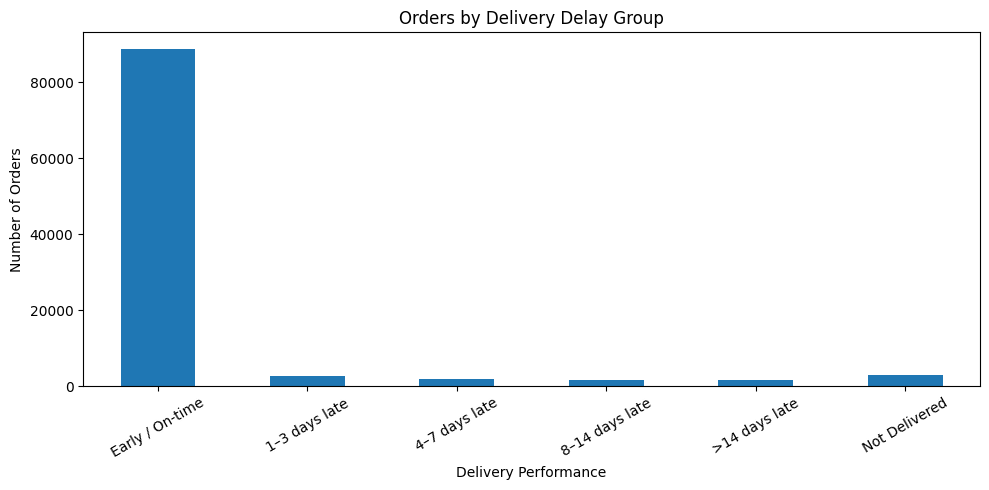

In [26]:
delay_order = [
    'Early / On-time',
    '1–3 days late',
    '4–7 days late',
    '8–14 days late',
    '>14 days late',
    'Not Delivered'
]

delay_counts = orders['delay_group'].value_counts()

delay_counts = delay_counts.reindex(
    delay_order
).dropna()

plt.figure(figsize=(10, 5))

delay_counts.plot(kind='bar')

plt.title('Orders by Delivery Delay Group')
plt.xlabel('Delivery Performance')
plt.ylabel('Number of Orders')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [27]:
orders['seller_handling_days'] = (
    orders['order_delivered_carrier_date']
    - orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

print("========== SELLER HANDLING TIME ==========")

print(
    orders['seller_handling_days']
    .describe()
)

========== SELLER HANDLING TIME ==========
count    97658.000000
mean         3.234050
std          3.611996
min       -171.212419
25%          1.128967
50%          2.204676
75%          4.071777
max        125.775521
Name: seller_handling_days, dtype: float64


In [28]:
orders['transit_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_delivered_carrier_date']
).dt.total_seconds() / (24 * 60 * 60)

print("========== TRANSIT TIME ==========")

print(
    orders['transit_days']
    .describe()
)

========== TRANSIT TIME ==========
count    96475.000000
mean         9.330547
std          8.760122
min        -16.096169
25%          4.099948
50%          7.099769
75%         12.029115
max        205.190972
Name: transit_days, dtype: float64


In [29]:
delivery_by_status = pd.crosstab(
    orders['order_status'],
    orders['delivery_status'],
    normalize='index'
).mul(100).round(2)

print(delivery_by_status)

delivery_status  Early / On-time  Late  Not Delivered
order_status                                         
approved                    0.00  0.00         100.00
canceled                    0.80  0.16          99.04
created                     0.00  0.00         100.00
delivered                  91.88  8.11           0.01
invoiced                    0.00  0.00         100.00
processing                  0.00  0.00         100.00
shipped                     0.00  0.00         100.00
unavailable                 0.00  0.00         100.00


In [30]:
print("========== ORDERS DATA QUALITY SUMMARY ==========")

print("Total rows:", len(orders))
print("Unique orders:", orders['order_id'].nunique())
print("Duplicate rows:", orders.duplicated().sum())

print("\nMissing values:")
display(
    pd.DataFrame({
        'Missing_Count': orders.isna().sum(),
        'Missing_%': (orders.isna().mean() * 100).round(2)
    })
)

print("\nOrder status:")
print(orders['order_status'].value_counts())

print("\nDelivery status:")
print(orders['delivery_status'].value_counts())

========== ORDERS DATA QUALITY SUMMARY ==========
Total rows: 99441
Unique orders: 99441


Duplicate rows: 0

Missing values:


,Missing_Count,Missing_%
order_id,0,0.00
customer_id,0,0.00
order_status,0,0.00
order_purchase_timestamp,0,0.00
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98
order_estimated_delivery_date,0,0.00
order_month,0,0.00
delivery_delay_days,2965,2.98



Order status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Delivery status:
delivery_status
Early / On-time    88649
Late                7827
Not Delivered       2965
Name: count, dtype: int64
